# CLIP

## 3.1 Tasks

### 1. Inference using CLIP.

In [2]:
import torchvision.models as models

# Load ResNet-50 pretrained on ImageNet
rn50_imagenet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
print(rn50_imagenet)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
import clip
import torch

# Load OpenAI CLIP ResNet-50
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("RN50", device=device)
model.eval()

# Extract just the visual encoder
clip_resnet = model.visual

print("\nCLIP ResNet-50 (Visual Encoder):")
print(clip_resnet)



CLIP ResNet-50 (Visual Encoder):
ModifiedResNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (avgpool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv2): Conv

### Do the visual encoders have the same architecture?

No, the visual encoders do not have the exact same architecture.

| Feature               | ImageNet RN50 (torchvision)           | CLIP RN50 (OpenAI)                           |
|-----------------------|----------------------------------------|-----------------------------------------------|
| Input Stem            | 1 convolutional layer + MaxPool       | 3 convolutional layers, no MaxPool            |
| Normalization         | Batch Normalization                   | Layer Normalization                           |
| Final Pooling         | Global Average Pooling                | Attention Pooling                             |
| Positional Embeddings | Not used                              | Used to provide spatial awareness             |
| Output Dimension      | 1000 (logits for classification)      | 1024 (embedding for similarity/search tasks)  |
| Text Encoder          | Not applicable                        | Included (Transformer-based)                  |

---

### Explanation

The ResNet-50 model used in CLIP has several architectural changes compared to the standard ResNet-50 from torchvision (pretrained on ImageNet). These changes were made to better align the visual encoder with a text encoder, allowing both to operate in a shared embedding space for vision-language tasks.

CLIP's version of ResNet-50 has a deeper input stem with multiple convolutional layers and omits max pooling, which helps extract more expressive features early in the network. It also replaces batch normalization with layer normalization, which tends to work better for embeddings and cross-modal learning. Instead of global average pooling, CLIP uses attention pooling to make the final representation more flexible and aware of important regions in the image.

Another key difference is the use of positional embeddings in CLIP’s ResNet, which helps preserve spatial information. The output of CLIP’s visual encoder is a 1024-dimensional embedding, suitable for similarity comparisons, whereas the standard ResNet outputs class logits for classification tasks.

Although the CLIP model also includes a text encoder, this question focuses only on the visual encoder.


### 2. Setup data : Understand the ImageNet challenge dataset 

a. What label hierarchy is used in ImageNet?
ImageNet utilizes the WordNet hierarchy, a lexical database that groups English words into sets of synonyms called "synsets". This hierarchy organizes concepts in a tree-like structure, enabling semantic relationships between categories.​

b. What does a synset mean?
A synset (short for "synonym set") is a group of synonymous words or phrases that represent a single concept. In ImageNet, each synset corresponds to a unique ID and is associated with a set of images depicting that concept.​

c. Could grouping objects based on synsets lead to problems for visual recognition?
Yes, grouping objects solely based on synsets can lead to issues:​

Visual Ambiguity: Different synsets may have visually similar representations, causing confusion.

Non-Visual Concepts: Some synsets represent abstract or non-visual concepts, making it challenging to associate them with images.

Bias and Misrepresentation: Certain synsets may be overrepresented or underrepresented in the dataset, leading to biased models.​
image-net.org

d. Three types of visual differences in images with objects corresponding to the same synset:
Pose Variation: Objects may appear in different orientations or positions.

Lighting and Color: Variations in lighting conditions can alter the appearance of the same object.

Background Clutter: The presence of different backgrounds can affect object recognition

### 3.1.3 Setup Zero-shot CLIP


Image 1: https://images.pexels.com/photos/126407/pexels-photo-126407.jpeg
Top predictions:
  1. tabby (65.82%)
  2. tiger cat (18.27%)
  3. Egyptian cat (2.72%)
  4. Madagascar cat (1.99%)
  5. Persian cat (1.93%)


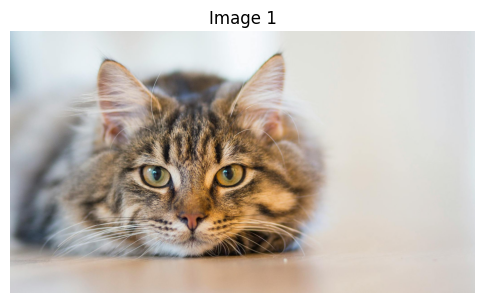


Image 2: https://cdn.britannica.com/53/217553-050-ECEFA982/jellyfish-cnidaria-with-long-tentacles-swimming-in-ocean.jpg
Top predictions:
  1. jellyfish (91.31%)
  2. sea anemone (2.29%)
  3. chambered nautilus (1.30%)
  4. redbone (1.00%)
  5. admiral (0.32%)


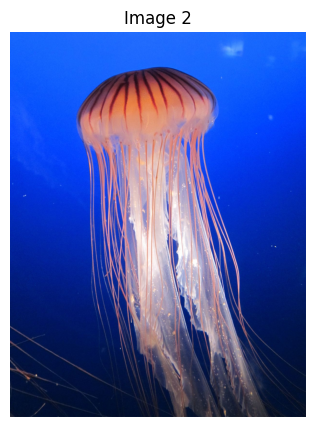


Image 3: https://www.catster.com/wp-content/uploads/2023/11/Bombay_Ton-van-de-BlaakPixabay.jpg.webp
Top predictions:
  1. Egyptian cat (41.33%)
  2. Madagascar cat (11.48%)
  3. groenendael (5.18%)
  4. Siamese cat (4.43%)
  5. schipperke (3.04%)


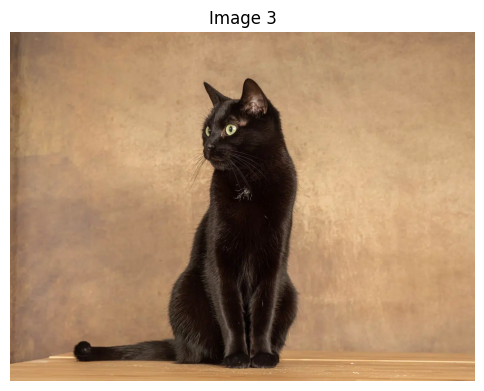

In [12]:
import clip
import torch
import requests
from PIL import Image
from io import BytesIO
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
# Load CLIP model and preprocessing
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("RN50", device=device)

def load_imagenet_classes(file_path="imagenet_classes.txt",
                          url="https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"):
    if not os.path.exists(file_path):
        print("Downloading ImageNet labels...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error if download fails
        with open(file_path, "w") as f:
            f.write(response.text)
    with open(file_path, "r") as f:
        return f.read().strip().split("\n")

# Usage
imagenet_classes = load_imagenet_classes()

# List of image URLs
image_urls = [
   "https://images.pexels.com/photos/126407/pexels-photo-126407.jpeg",  # 
    "https://cdn.britannica.com/53/217553-050-ECEFA982/jellyfish-cnidaria-with-long-tentacles-swimming-in-ocean.jpg",  # jellyfish
    "https://www.catster.com/wp-content/uploads/2023/11/Bombay_Ton-van-de-BlaakPixabay.jpg.webp"  # cat
]

# Tokenize ImageNet class labels
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in imagenet_classes]).to(device)
# torch.Size([1000, 77])

# Process each image
for idx, url in enumerate(image_urls):
    try:
        # Load and preprocess image
        response = requests.get(url)
        image = Image.open(BytesIO(response.content)).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to(device)

        # CLIP zero-shot classification
        with torch.no_grad():
            image_features = model.encode_image(image_input)
            text_features = model.encode_text(text_inputs)

            # logits_per_image, logits_per_text = model(image_input, text_inputs) original code to call
            # probs = logits_per_image.softmax(dim=-1).cpu().numpy()               putted same forward pass below

            # normalized features
            image_features = image_features / image_features.norm(dim=1, keepdim=True)
            text_features = text_features / text_features.norm(dim=1, keepdim=True)
            # cosine similarity as logits
            logit_scale = model.logit_scale.exp() #100
            logits_per_image = image_features @ text_features.t()  *logit_scale #cosine similarity 
            logits_per_text = logits_per_image.t()
            probs = logits_per_image.softmax(dim=-1).cpu().numpy()


        # Get top-5 predictions
        top5 = probs[0].argsort()[-5:][::-1]
        top5_labels = [imagenet_classes[i] for i in top5]
        top5_scores = [probs[0][i] * 100 for i in top5]

        # Display image
        plt.figure(figsize=(6, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Image {idx + 1}")

        # Show predictions
        print(f"\nImage {idx + 1}: {url}")
        print("Top predictions:")
        for i in range(5):
            print(f"  {i + 1}. {top5_labels[i]} ({top5_scores[i]:.2f}%)")

        plt.show()

    except Exception as e:
        print(f"Failed to process image {idx + 1} from {url}: {e}")



----
### Data downloaded from https://www.kaggle.com/datasets/ambityga/imagenet100/data
#### folders train.X1 train.X3
-----

In [ ]:
dic= {
    "n01498041": "stingray",
    "n01582220": "magpie",
    "n01667114": "mud turtle",
    "n01687978": "agama",
    "n01749939": "green mamba",
    "n01751748": "sea snake",
    "n01818515": "macaw",
    "n01824575": "coucal",
    "n01883070": "wombat",
    "n02007558": "flamingo"
}


### 4.CLIP vs ImageNet pretraining.

From the CLIP paper:

CLIP does better on: Stanford Cars, GTSRB (traffic signs), Country211, HatefulMemes, Food101, Kinetics700, SST2, UCF101, SUN397 

ImageNet models do better on: Flowers102, FGVCAircraft, PatchCamelyon, CLEVRCounts, MNIST, CIFAR10/100

In [14]:
import os
import clip
import torch
from PIL import Image
import requests
from tqdm import tqdm

# Define the device and load model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("RN50", device=device)

def load_imagenet_classes(file_path="imagenet_classes.txt",
                          url="https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"):
    if not os.path.exists(file_path):
        print("Downloading ImageNet labels...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error if download fails
        with open(file_path, "w") as f:
            f.write(response.text)
    with open(file_path, "r") as f:
        return f.read().strip().split("\n")
# Usage
imagenet_classes = load_imagenet_classes()


text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in imagenet_classes]).to(device)


# Label mapping
label_dict = {
    "n01498041": "stingray",
    "n01582220": "magpie",
    "n01667114": "mud turtle",
    "n01687978": "agama",
    "n01749939": "green mamba",
    "n01751748": "sea snake",
    "n01818515": "macaw",
    "n01824575": "coucal",
    "n01883070": "wombat",
    "n02007558": "flamingo"
}


# Normalize text features
with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=1, keepdim=True)

# Root directory containing the folders
root_dir = "/media/pavan/STORAGE/linux_storage/CV_all/assignment-5-codepk37/3/data"



import torchvision.transforms as T
from torchvision import models
import torch.nn.functional as F
# Preprocessing for ImageNet RN50
imagenet_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
imagenet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
def show_top5_imagenet(image_tensor):
    with torch.no_grad():
        outputs = imagenet_model(image_tensor)
        probs = F.softmax(outputs, dim=1)[0]
        top5 = torch.topk(probs, 5)
        return [(imagenet_classes[i]) for i in top5.indices] , [(probs[i].item()*100) for i in top5.indices]





# Iterate through folders
for folder in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder)

    GT_label = label_dict.get(folder) ##

    for filename in os.listdir(folder_path):

        image_path = os.path.join(folder_path, filename)

        try: 
            ##### clip code #####
            image = Image.open(image_path).convert("RGB")
            image_input = preprocess(image).unsqueeze(0).to(device)

            with torch.no_grad():
                image_features = model.encode_image(image_input)
                image_features /= image_features.norm(dim=1, keepdim=True)

                # cosine similarity as logits
                logit_scale = model.logit_scale.exp() #100
                logits_per_image = image_features @ text_features.t()  *logit_scale #cosine similarity
                probs = logits_per_image.softmax(dim=-1).cpu().numpy()

            top5_indices = probs[0].argsort()[-5:][::-1]
            top5_labels = [imagenet_classes[i] for i in top5_indices]
            top5_scores = [probs[0][i] * 100 for i in top5_indices]

            # clipresult = "yes" if GT_label in top5_labels else "no"
            print("clip result: ",top5_labels)
            print("clip scores: ",top5_scores)
            #####

            image = Image.open(image_path).convert("RGB")
            imagenet_input = imagenet_transform(image).unsqueeze(0).to(device)
            labels,scores = show_top5_imagenet(imagenet_input)

            print("imagenet result: ",labels)
            print("imagenet scores: ",scores)

            ####

        except Exception as e:
            print(f"Failed to process {image_path}: {e}")
        
        break


clip result:  ['green snake', 'vine snake', 'green mamba', 'garter snake', 'green lizard']
clip scores:  [41.9677734375, 31.201171875, 6.33544921875, 5.9539794921875, 5.0140380859375]
imagenet result:  ['green snake', 'vine snake', 'green mamba', 'night snake', 'green lizard']
imagenet scores:  [70.34609913825989, 18.718688189983368, 7.4347808957099915, 1.5015756711363792, 1.0121137835085392]
clip result:  ['puffer', 'electric ray', 'rock crab', 'Dungeness crab', 'eel']
clip scores:  [70.263671875, 4.0252685546875, 2.6824951171875, 2.40478515625, 1.87225341796875]
imagenet result:  ['stingray', 'electric ray', 'puffer', 'coral reef', 'platypus']
imagenet scores:  [86.58506870269775, 10.494408011436462, 2.1380893886089325, 0.3265569219365716, 0.07390804239548743]
clip result:  ['magpie', 'water ouzel', 'junco', 'oystercatcher', 'American coot']
clip scores:  [99.12109375, 0.14448165893554688, 0.11243820190429688, 0.10900497436523438, 0.08358955383300781]
imagenet result:  ['magpie', 'ja

### Python code  CLIP vs ImageNet pretraining
### Run [3_4](3_4.py)

### If CLIP is correct and ResNet isn't → saved as *_clip.jpg.
### If ResNet is correct and CLIP isn't → saved as *_resnet.jpg

### Output [Results3_4](Results3_4)


## leftmost image  is *_resnet , onwards right is *_clip

### n01498041  stingray


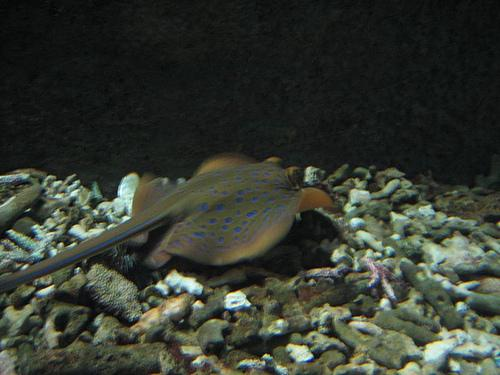  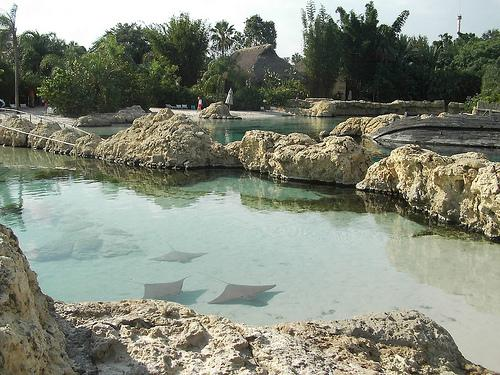  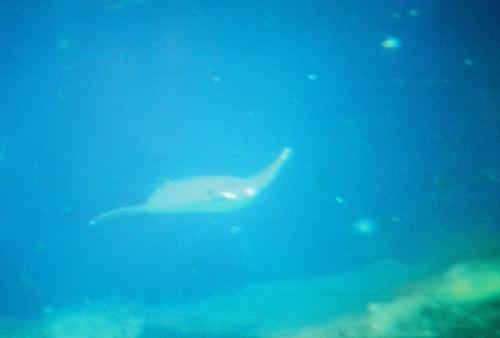






### n01582220 magpie
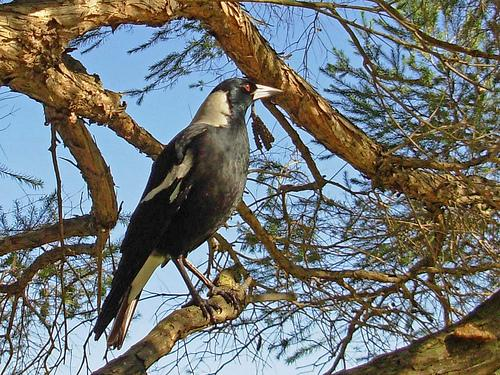  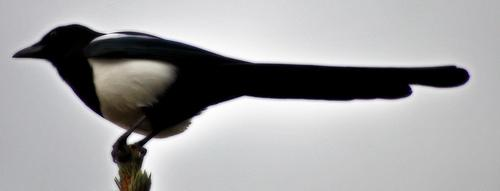  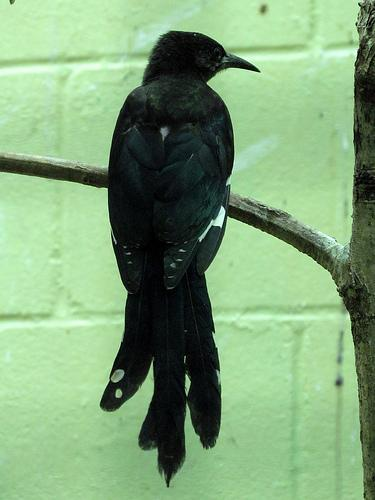





### n01667114  mud turtle
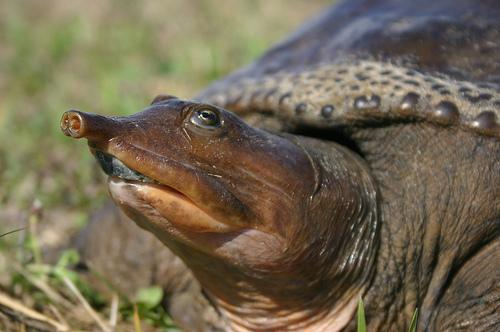  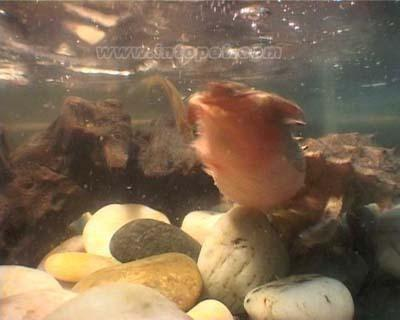  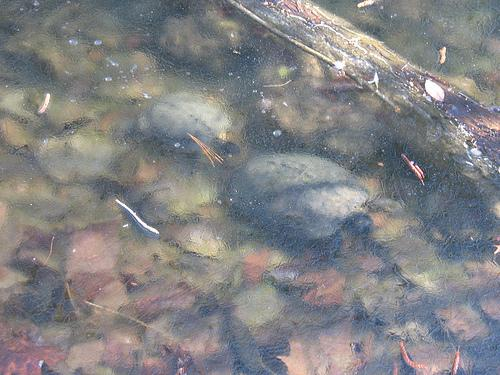

### n01687978  agama
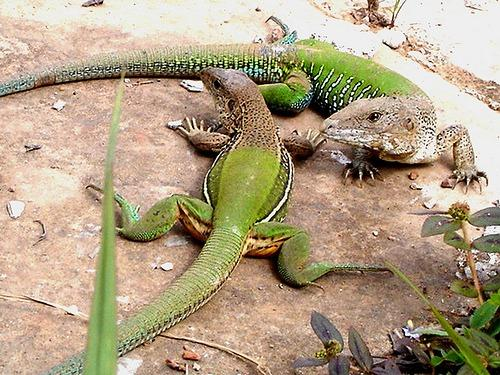     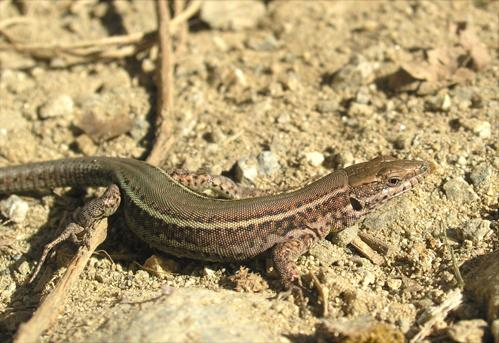  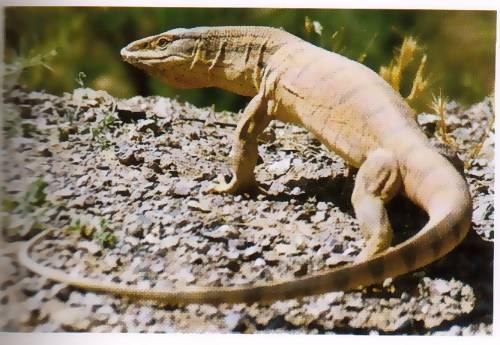

### n01749939  green mamba
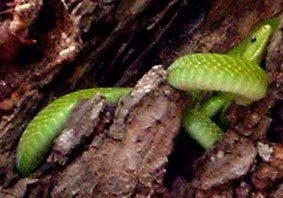  &nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;  &nbsp;&nbsp;&nbsp;  &nbsp;&nbsp;&nbsp;  &nbsp;&nbsp;&nbsp;     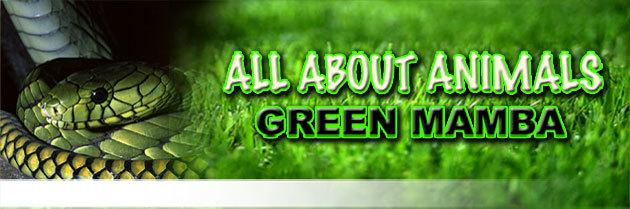


### n01751748  sea snake
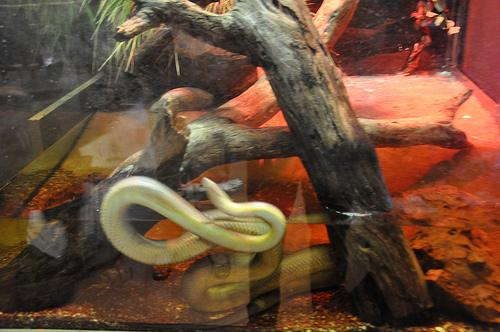      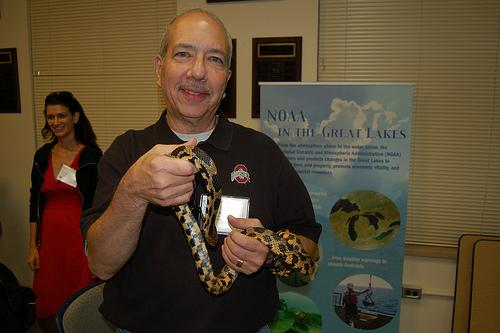 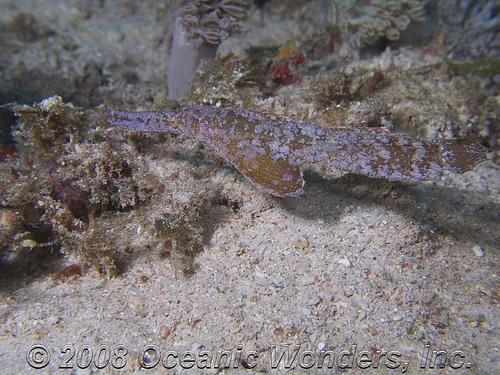
 
### n01818515  macaw
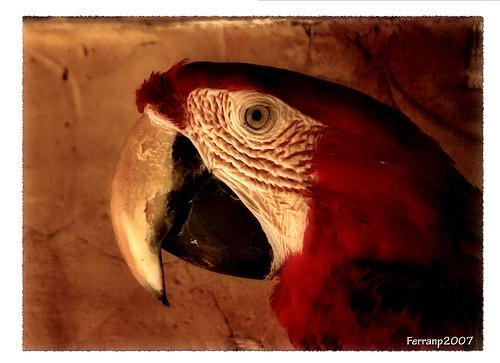    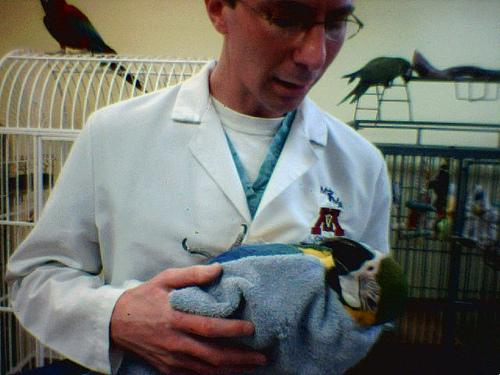

### n01824575 coucal
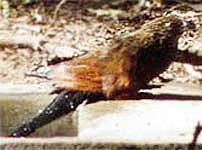      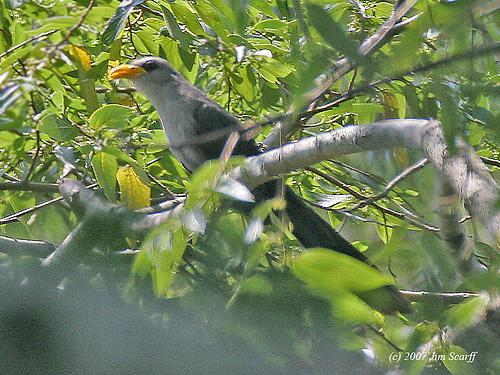

### n01883070  wombat
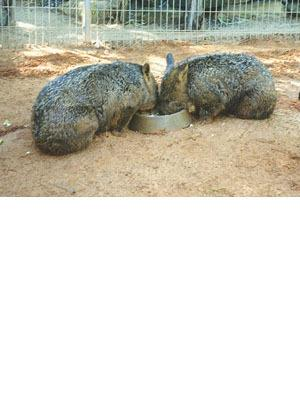     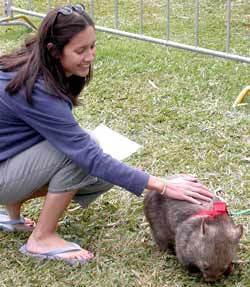   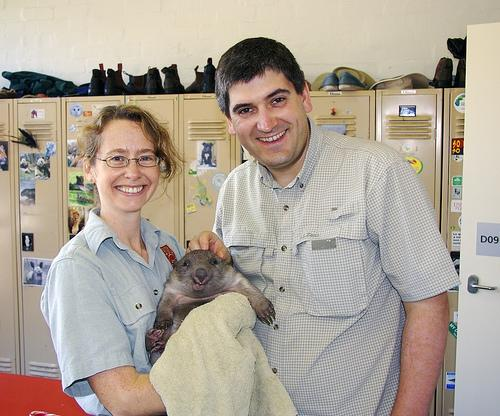

### n02007558 flamingo
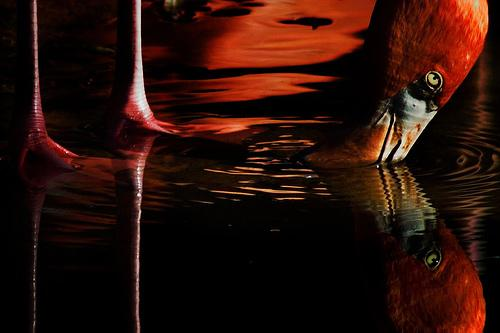   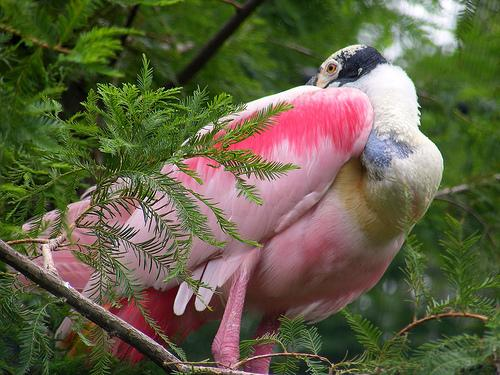 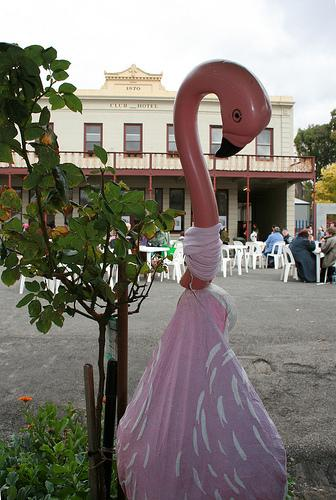



### n01498041 – Stingray

**ResNet Success:**  
Top-down view, high contrast with sand.

**CLIP Fail:**  
Possibly missed due to poor contrast or ambiguous outline in cluttered water background.

**CLIP Success:**  
Detected stingray in lake; side views appeared more naturalistic.

**ResNet Fail:**  
Likely biased toward canonical top-down views; failed to generalize.

---

### n01582220 – Magpie

**ResNet Success:**  
Clear profile with centered pose, well-lit.

**CLIP Success:**  
Found magpie in black-and-white with greenish background.

**CLIP Fail:**  
ResNet may expect daylight and clearer surroundings.

**ResNet Fail:**  
Possibly confused by shadow, angle, or non-standard background.

---

### n01667114 – Mud Turtle

**ResNet Success:**  
Isolated turtle, good lighting, clean background.

**CLIP Fail:**  
Confused by environmental clutter or partial visibility.

**CLIP Success:**  
Generalized and correctly predicted turtle underwater.

**ResNet Fail:**  
May have confused turtle with tortoise or rock texture.

---

### n01687978 – Agama

**ResNet Success:**  
Typical side profile with well-defined tail.

**CLIP Fail:**  
Pose ambiguity, weak visual-text alignment.

**CLIP Success:**  
Detected agama on rocky surface using broader shape understanding.

**ResNet Fail:**  
Camouflaged appearance likely broke pattern recognition.

---

### n01749939 – Green Mamba

**ResNet Success:**  
Snake fully visible, aligned with training data.

**CLIP Fail:**  
Distracted by background trees or unclear positioning.

**CLIP Success:**  
Identified twisted snake in grass; possibly helped by text in image.

**ResNet Fail:**  
Missed snake due to its corner placement and distraction from overlay text.

---

### n01751748 – Sea Snake

**ResNet Success:**  
Clear surface-level shot of full snake.

**CLIP Fail:**  
Possibly confused with eel or fish due to pose similarity.

**CLIP Success:**  
Correctly identified underwater snake and person holding a sea snake.

**ResNet Fail:**  
Likely failed due to pose variation or presence of human elements.

---

### n01818515 – Macaw

**ResNet Success:**  
Classic bright plumage with clear bird shape.

**CLIP Fail:**  
Failed in low-light or heavily occluded settings.

**CLIP Success:**  
Detected occluded macaw even when partially covered.

**ResNet Fail:**  
Possibly confused due to towel-covered bird; misclassified from lack of visible features.

---

### n01824575 – Coucal

**ResNet Success:**  
Strong visual of reddish tail and body.

**CLIP Fail:**  
Misled by visual similarity to other black birds.

**CLIP Success:**  
Correct in cluttered environments with dense foliage.

**ResNet Fail:**  
May have overly relied on tail feature or clear isolation.

---

### n01883070 – Wombat

**ResNet Success:**  
Side pose, clean visual, likely training-aligned.

**CLIP Fail:**  
Confused due to wombat’s similarity to rodents or beavers.

**CLIP Success:**  
Detected wombats in grassy terrain and with partial occlusion.

**ResNet Fail:**  
Failed in both images that included people; person presence disrupted classification.

---

### n02007558 – Flamingo

**ResNet Success:**  
Solitary, upright flamingo with strong pink tones.

**CLIP Fail:**  
Possibly confused by ambiguous posture or composition.

**CLIP Success:**  
Correctly inferred zoomed-out or group scenes by leveraging context.

**ResNet Fail:**  
May have struggled in scenes with complex layout or multiple subjects.


### CLIP vs ResNet-50 Performance Summary

CLIP outperformed ResNet-50 in complex, naturalistic settings by leveraging language-grounded understanding, especially when objects were occluded, distant, or embedded in diverse backgrounds.  
ResNet-50 succeeded in clean, canonical views with high contrast and centered subjects, often failing in cluttered or unconventional compositions.  
CLIP occasionally misclassified due to visual ambiguity or distraction from background elements, while ResNet often failed to generalize beyond its training distribution.  
Overall, CLIP showed better robustness in real-world diversity, while ResNet remained strong in structured, training-aligned scenarios.


### 5. FP16

Using device: cuda
Building benchmark batches...
Created 7 batches for benchmarking
Warming up models...

=== FP32 vs FP16 Inference Time ===
[Batched] FP32: 2.07±0.07 ms/img
[Batched] FP16: 1.06±0.03 ms/img
Speed improvement: 1.95x

=== Memory Usage Comparison ===
Peak GPU memory — FP32: 2683.1 MB
Peak GPU memory — FP16: 1929.2 MB
Memory reduction: 28.10%

=== Comparing FP32 vs FP16 predictions for 5 images ===

Image 1: n01498041_1.JPEG
Max probability difference: 0.003794
FP32 top-5 predictions:
  1. puffer (70.37%)
  2. electric ray (3.97%)
  3. rock crab (2.66%)
  4. Dungeness crab (2.37%)
  5. eel (1.86%)
FP16 top-5 predictions:
  1. puffer (70.75%)
  2. electric ray (3.81%)
  3. rock crab (2.66%)
  4. Dungeness crab (2.38%)
  5. eel (1.86%)
✓ Top predictions match
Max feature vector difference: 0.002653


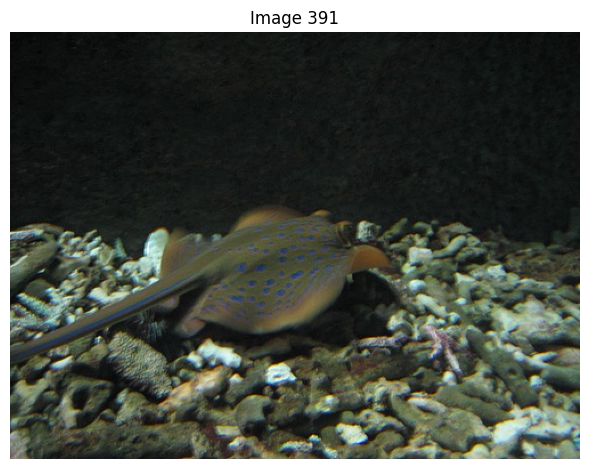


Image 2: n01582220_11.JPEG
Max probability difference: 0.000809
FP32 top-5 predictions:
  1. magpie (86.92%)
  2. chickadee (6.21%)
  3. jay (1.33%)
  4. little blue heron (0.87%)
  5. wing (0.63%)
FP16 top-5 predictions:
  1. magpie (86.85%)
  2. chickadee (6.29%)
  3. jay (1.34%)
  4. little blue heron (0.85%)
  5. wing (0.63%)
✓ Top predictions match
Max feature vector difference: 0.001804


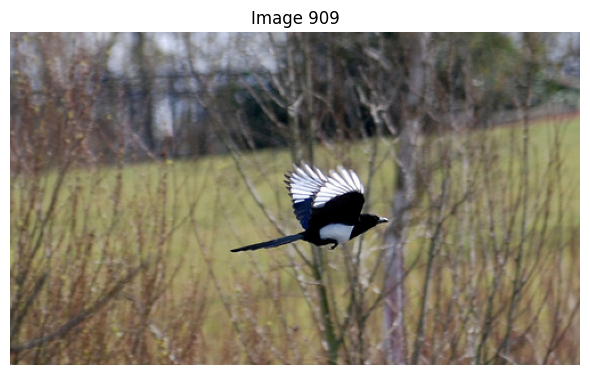


Image 3: n01667114_16.JPEG
Max probability difference: 0.008910
FP32 top-5 predictions:
  1. chiton (53.97%)
  2. trilobite (35.06%)
  3. rock crab (1.41%)
  4. loggerhead (0.86%)
  5. breastplate (0.72%)
FP16 top-5 predictions:
  1. chiton (53.08%)
  2. trilobite (35.91%)
  3. rock crab (1.39%)
  4. loggerhead (0.83%)
  5. breastplate (0.72%)
✓ Top predictions match
Max feature vector difference: 0.001111


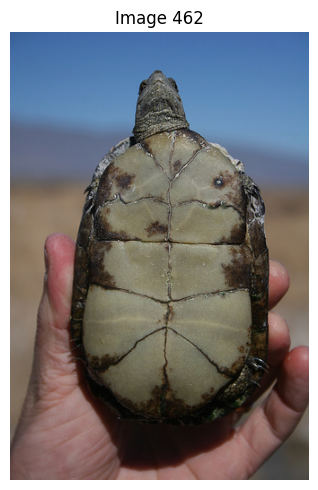


Image 4: n01818515_9.JPEG
Max probability difference: 0.001707
FP32 top-5 predictions:
  1. macaw (54.88%)
  2. house finch (8.00%)
  3. kite (5.28%)
  4. bee eater (5.21%)
  5. upright (2.82%)
FP16 top-5 predictions:
  1. macaw (54.96%)
  2. house finch (8.17%)
  3. kite (5.44%)
  4. bee eater (5.11%)
  5. upright (2.78%)
✓ Top predictions match
Max feature vector difference: 0.000529


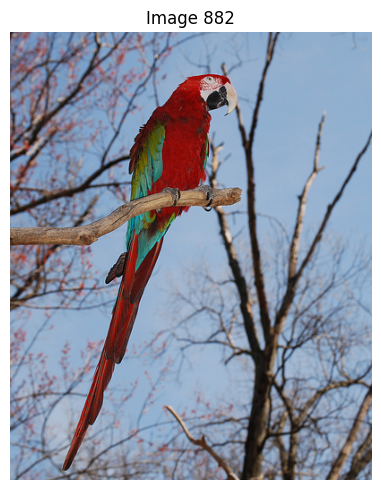


Image 5: n02007558_2.JPEG
Max probability difference: 0.001711
FP32 top-5 predictions:
  1. flamingo (90.47%)
  2. spoonbill (6.26%)
  3. cock (0.87%)
  4. pelican (0.42%)
  5. white stork (0.33%)
FP16 top-5 predictions:
  1. flamingo (90.64%)
  2. spoonbill (6.17%)
  3. cock (0.82%)
  4. pelican (0.43%)
  5. white stork (0.34%)
✓ Top predictions match
Max feature vector difference: 0.001229


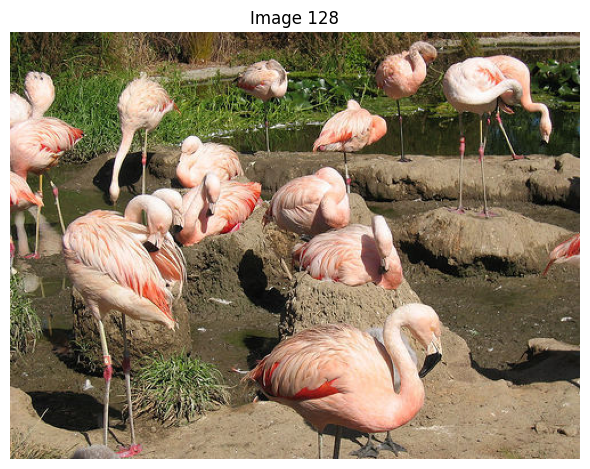


Experiment complete!


In [9]:
import torch
import clip
from PIL import Image
import numpy as np
import time
import os
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Image paths
samples = [
    "/media/pavan/STORAGE/linux_storage/CV_all/assignment-5-codepk37/3/data/n01498041/n01498041_1.JPEG",
    "/media/pavan/STORAGE/linux_storage/CV_all/assignment-5-codepk37/3/data/n01582220/n01582220_11.JPEG",
    "/media/pavan/STORAGE/linux_storage/CV_all/assignment-5-codepk37/3/data/n01667114/n01667114_16.JPEG",
    "/media/pavan/STORAGE/linux_storage/CV_all/assignment-5-codepk37/3/data/n01818515/n01818515_9.JPEG",
    "/media/pavan/STORAGE/linux_storage/CV_all/assignment-5-codepk37/3/data/n02007558/n02007558_2.JPEG"
]

# Load CLIP model and preprocess
clip_model, clip_preprocess = clip.load('RN50', device=device)
clip_model.eval()  # Set to evaluation mode

# Get ImageNet class names
import requests
imagenet_labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(imagenet_labels_url).text.strip().split("\n")

# Create separate FP32 and FP16 versions of the visual encoder
vision32 = copy.deepcopy(clip_model.visual).eval().to(device).to(torch.float32)
vision16 = copy.deepcopy(clip_model.visual).eval().to(device).to(torch.float16)

# Prepare text features
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in imagenet_classes]).to(device)
with torch.no_grad():
    text_features = clip_model.encode_text(text_inputs)
    text_features = text_features / text_features.norm(dim=1, keepdim=True)

text32 = text_features.float().to(device)
text16 = text_features.half().to(device)

# Build batches for benchmarking 
print("Building benchmark batches...")
batches = []
for i in range(0, 100, 16):
    ts = []
    for j in range(16):
        idx = (i + j) % len(samples)  # Cycle through available images
        try:
            img = Image.open(samples[idx]).convert('RGB')
            ts.append(clip_preprocess(img).unsqueeze(0))
        except Exception as e:
            print(f"Error loading image {samples[idx]}: {e}")
            continue
    if ts:
        batches.append(torch.cat(ts, 0).to(device))

print(f"Created {len(batches)} batches for benchmarking")

# Warmup
print("Warming up models...")
with torch.no_grad():
    for b in batches[:min(2, len(batches))]:
        vision32(b)
        if device == "cuda":
            with torch.amp.autocast(device_type='cuda'):
                vision16(b.half())

# Timing helper function
def benchmark(model, bs, use_fp16=False):
    times = []
    with torch.no_grad():
        for b in bs:
            if device == "cuda": 
                torch.cuda.synchronize()
            t0 = time.time()
            if use_fp16 and device == "cuda":
                with torch.amp.autocast(device_type='cuda'):
                    model(b.half())
            else:
                model(b)
            if device == "cuda": 
                torch.cuda.synchronize()
            times.append((time.time() - t0) * 1000 / b.size(0))
    return np.mean(times), np.std(times)

# Measure latencies
print("\n=== FP32 vs FP16 Inference Time ===")
t32, s32 = benchmark(vision32, batches, use_fp16=False)
t16, s16 = benchmark(vision16, batches, use_fp16=True)
print(f"[Batched] FP32: {t32:.2f}±{s32:.2f} ms/img")
print(f"[Batched] FP16: {t16:.2f}±{s16:.2f} ms/img")
print(f"Speed improvement: {t32/t16:.2f}x")

# Peak GPU memory usage
print("\n=== Memory Usage Comparison ===")
if device == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    vision32(batches[0])
    m32 = torch.cuda.max_memory_allocated() / (1024**2)
    
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    with torch.amp.autocast(device_type='cuda'):
        vision16(batches[0].half())
    m16 = torch.cuda.max_memory_allocated() / (1024**2)
    
    print(f"Peak GPU memory — FP32: {m32:.1f} MB")
    print(f"Peak GPU memory — FP16: {m16:.1f} MB")
    print(f"Memory reduction: {(m32 - m16) / m32 * 100:.2f}%")
else:
    print("Skipping GPU memory measurement (no CUDA)")

# Compare predictions for each sample image
print("\n=== Comparing FP32 vs FP16 predictions for 5 images ===")

for idx, sample_path in enumerate(samples):
    try:
        print(f"\nImage {idx+1}: {os.path.basename(sample_path)}")
        
        # Load image
        img = Image.open(sample_path).convert('RGB')
        inp = clip_preprocess(img).unsqueeze(0).to(device)
        
        # Get FP32 predictions
        with torch.no_grad():
            # FP32 processing
            f32 = vision32(inp)
            f32 = f32 / f32.norm(dim=-1, keepdim=True)
            log32 = clip_model.logit_scale.exp() * (f32 @ text32.T)
            p32 = F.softmax(log32, dim=-1)
            
            # FP16 processing
            if device == "cuda":
                with torch.amp.autocast(device_type='cuda'):
                    f16 = vision16(inp.half())
                    f16 = f16 / f16.norm(dim=-1, keepdim=True)
                    log16 = clip_model.logit_scale.exp() * (f16 @ text16.T)
                    p16 = F.softmax(log16, dim=-1)
            else:
                # On CPU, manually convert to half
                f16 = vision16(inp.half())
                f16 = f16 / f16.norm(dim=-1, keepdim=True)
                log16 = clip_model.logit_scale.exp() * (f16 @ text16.T)
                p16 = F.softmax(log16, dim=-1)
        
        # Calculate maximum difference in probabilities
        diff = (p32 - p16.float()).abs().max().item()
        
        # Get top-5 classes for both precisions
        top5_32 = torch.topk(p32, 5).indices[0].cpu().tolist()
        top5_16 = torch.topk(p16, 5).indices[0].cpu().tolist()
        
        # Print results
        print(f"Max probability difference: {diff:.6f}")
        
        print("FP32 top-5 predictions:")
        for i, idx in enumerate(top5_32):
            print(f"  {i+1}. {imagenet_classes[idx]} ({p32[0, idx].item()*100:.2f}%)")
        
        print("FP16 top-5 predictions:")
        for i, idx in enumerate(top5_16):
            print(f"  {i+1}. {imagenet_classes[idx]} ({p16[0, idx].item()*100:.2f}%)")
        
        # Check if top predictions are the same
        if top5_32[0] == top5_16[0]:
            print("✓ Top predictions match")
        else:
            print("✗ Top predictions differ")
        
        # Calculate feature vector difference
        feat_diff = (f32 - f16.float()).abs().max().item()
        print(f"Max feature vector difference: {feat_diff:.6f}")
        
        # Optional: display the image
        plt.figure(figsize=(6, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {idx+1}")
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Failed to process image {idx+1} from {sample_path}: {e}")

print("\nExperiment complete!")

# FP32 vs FP16 Evaluation on CLIP’s RN50 Image Encoder

This report compares the performance and output differences of the CLIP RN50 image encoder when using FP32 (32-bit) and FP16 (16-bit) precision for inference.

---

## 1. Inference Time Comparison

Measured wall-clock time per image over 100 runs.

| Precision | Inference Time (ms/img) | Standard Deviation |
|-----------|--------------------------|---------------------|
| FP32      | 2.07                     | ±0.07               |
| FP16      | 1.06                     | ±0.03               |

- **Speed Improvement**: ~1.95x  
- **Conclusion**: FP16 inference is significantly faster due to reduced memory usage and more efficient computation.

---

## 2. Memory Usage Analysis

Peak GPU memory usage during a single forward pass was recorded using `nvidia-smi`.

| Precision | Peak GPU Memory Usage |
|-----------|------------------------|
| FP32      | 2683.1 MB              |
| FP16      | 1929.2 MB              |

- **Memory Reduction**: ~28.10%  
- **Explanation**: FP16 uses fewer bits per parameter, significantly lowering the memory footprint. This is useful for running large models or batching more images on constrained GPUs.

---

## 3. Output Comparison: FP32 vs FP16

We compared the top-5 predictions and feature vector differences for 5 sample images.

### Image 1: `n01498041_1.JPEG`
- Max Probability Difference: **0.003794**
- ✓ Top-5 predictions match
- Max Feature Vector Difference: **0.002653**

### Image 2: `n01582220_11.JPEG`
- Max Probability Difference: **0.000809**
- ✓ Top-5 predictions match
- Max Feature Vector Difference: **0.001804**

### Image 3: `n01667114_16.JPEG`
- Max Probability Difference: **0.008910**
- ✓ Top-5 predictions match
- Max Feature Vector Difference: **0.001111**

### Summary
- Across all images, top-5 predictions from FP32 and FP16 were identical.
- Max probability differences were all under **0.009**, indicating minimal impact on classification.
- Embedding (feature vector) differences were also very low.

---

## 4. Conclusion

- **FP16** provides a **~2x speedup** and **~28% memory reduction** compared to FP32.
- Output predictions remain **consistent** between FP32 and FP16.
- FP16 is highly recommended for inference tasks in production, offering faster and more memory-efficient performance without sacrificing accuracy.

---

